<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/02_Notion_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notion Google Play Review EDA**

## **⚙️ Process Description**

| Stage | Description |
|------|------------|
| Overview | Exploratory analysis was conducted to understand the overall structure and distribution of the dataset before preprocessing. |
| Data Quality Check | The dataset was examined for data types, missing values, and duplicate entries to ensure data consistency and reliability. |
| Rating Distribution | The distribution of user scores was analyzed to identify general patterns in user feedback. |
| Temporal Analysis | Review data was analyzed over time to observe trends and changes in user activity across different years. |
| Text Analysis | Text-based exploration was performed, including analysis of review length and identification of frequently used words. |

### **Setup & Data Loading**

In [44]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install nltk

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
import ast

In [20]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Tugas Individu/Dataset/review_notion_raw.csv')

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,acfbcf53-ca8a-40b3-a92e-d94447da864f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"had a payment issue, the SAV solved it quickly.",5,0,NaN,2026-04-29 16:35:03,NaN,NaN,NaN
1,ae9206ec-742a-417e-a83a-7c5536ec50f5,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,NaN,NaN,0.6.3809
2,9f587909-e254-4d20-a2f1-440cd989727d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"I loved this app, but my documents keep going ...",3,0,NaN,2026-04-29 10:38:49,NaN,NaN,NaN
3,ab75d7d3-340f-40a9-aa88-23bed04f99a7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,powerful (All in 1). but new ke liye itna jada...,1,0,NaN,2026-04-29 09:22:59,NaN,NaN,NaN
4,28454e31-ae36-41d5-b1b5-11ee19f36fa7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Very bad mobile experience. Everything is so s...,1,0,0.6.3803,2026-04-28 20:29:03,NaN,NaN,0.6.3803


### **Data Overview & Quality Check**

In [4]:
# Basic structure
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
# Missing values analysis
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (23114, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23114 entries, 0 to 23113
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              23114 non-null  object
 1   userName              23114 non-null  object
 2   userImage             23114 non-null  object
 3   content               23114 non-null  object
 4   score                 23114 non-null  int64 
 5   thumbsUpCount         23114 non-null  int64 
 6   reviewCreatedVersion  20248 non-null  object
 7   at                    23114 non-null  object
 8   replyContent          161 non-null    object
 9   repliedAt             161 non-null    object
 10  appVersion            20248 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.9+ MB
None

Missing Values:
reviewId                    0
userName                    0
userImage                   0
content                     0
score                  

In [21]:
# First few rows to understand the content
df.head(3)

,reviewid,username,userimage,content,score,thumbsupcount,reviewcreatedversion,at,replycontent,repliedat,appversion,content_length,sentiment
0,acfbcf53-ca8a-40b3-a92e-d94447da864f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"had a payment issue, the SAV solved it quickly.",5,0,NaN,2026-04-29 16:35:03,NaN,NaN,NaN,47,Positive
1,ae9206ec-742a-417e-a83a-7c5536ec50f5,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,NaN,NaN,0.6.3809,325,Negative
2,9f587909-e254-4d20-a2f1-440cd989727d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"I loved this app, but my documents keep going ...",3,0,NaN,2026-04-29 10:38:49,NaN,NaN,NaN,53,Neutral


In [22]:
# Statistical summary of numeric columns
df.describe()


,score,thumbsupcount,content_length
count,23114.000000,23114.000000,23114.000000
mean,3.756165,2.526348,116.736869
std,1.524483,15.822924,126.693236
min,1.000000,0.000000,1.000000
25%,3.000000,0.000000,26.000000
50%,5.000000,0.000000,69.000000
75%,5.000000,1.000000,162.000000
max,5.000000,953.000000,1976.000000


In [23]:
# Check duplicate statistics using groupby approach

# Count duplicate review IDs
dup_reviewid = df.groupby('reviewid').size()
dup_reviewid_count = (dup_reviewid > 1).sum()

# Count duplicate content
dup_content = df.groupby('content').size()
dup_content_count = (dup_content > 1).sum()

print("Duplicate ReviewID entries :", dup_reviewid_count)
print("Duplicate Content entries  :", dup_content_count)


# Show most frequent duplicated content
duplicate_texts = dup_content[dup_content > 1].sort_values(ascending=False)

if not duplicate_texts.empty:
    print("\nTop duplicated review contents:")
    print(duplicate_texts.head(5))

Duplicate ReviewID entries : 0
Duplicate Content entries  : 411

Top duplicated review contents:
content
good         177
Good          79
nice          66
great app     54
Great app     51
dtype: int64


### **Score Distribution & Analysis**

In [24]:
# Calculate frequency of each score
df_count = (
    df['score']
    .value_counts()
    .sort_index()
    .rename_axis('score')
    .reset_index(name='count')
)

df_count

,score,count
0,1,3677
1,2,1891
2,3,2628
3,4,3113
4,5,11805


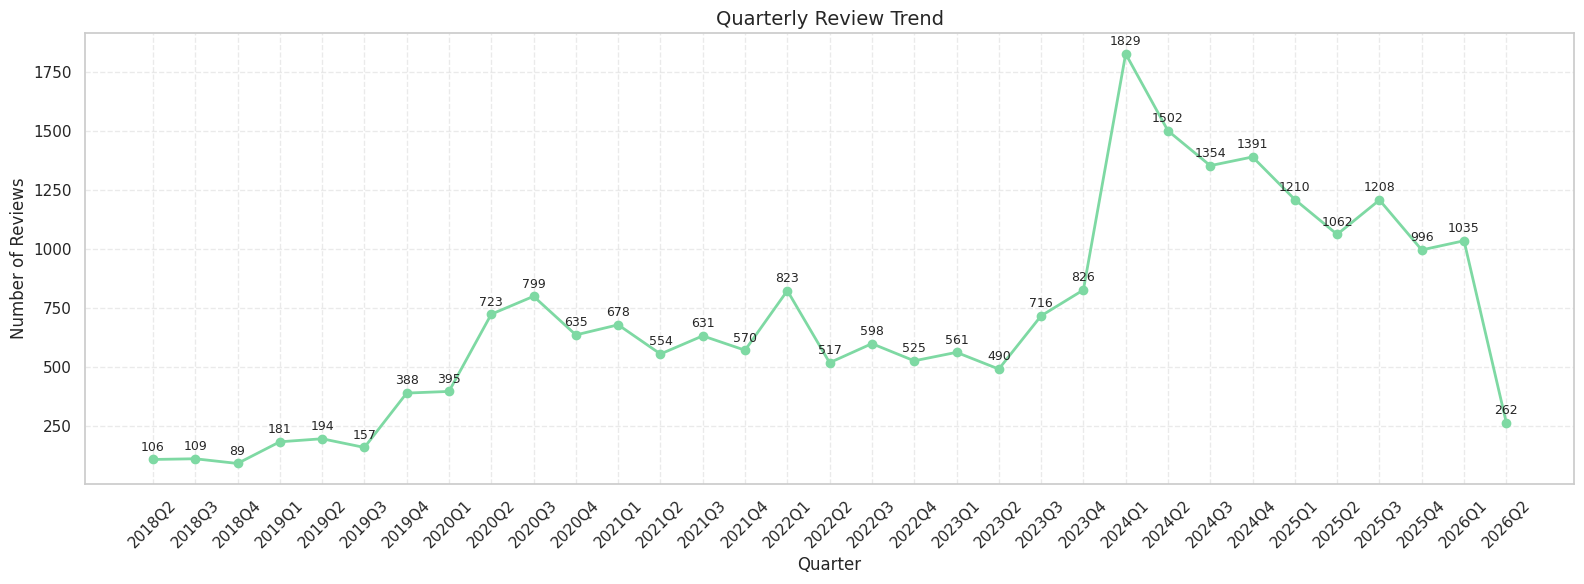

In [55]:
# Convert ke quarter
df['quarter'] = df['at'].dt.to_period('Q')

quarter_trend = df.groupby('quarter').size()
quarter_trend.index = quarter_trend.index.astype(str)

# Plot (lebih lebar)
plt.figure(figsize=(16,6))  # ← diperlebar

plt.plot(
    quarter_trend.index,
    quarter_trend.values,
    marker='o',
    linewidth=2,
    color="#7ED9A3"  # ← hijau dari palette kamu
)

# Add labels
max_val = quarter_trend.values.max()
for x, y in zip(range(len(quarter_trend)), quarter_trend.values):
    plt.text(
        x,
        y + max_val*0.02,
        str(y),
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=45)

plt.title("Quarterly Review Trend", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

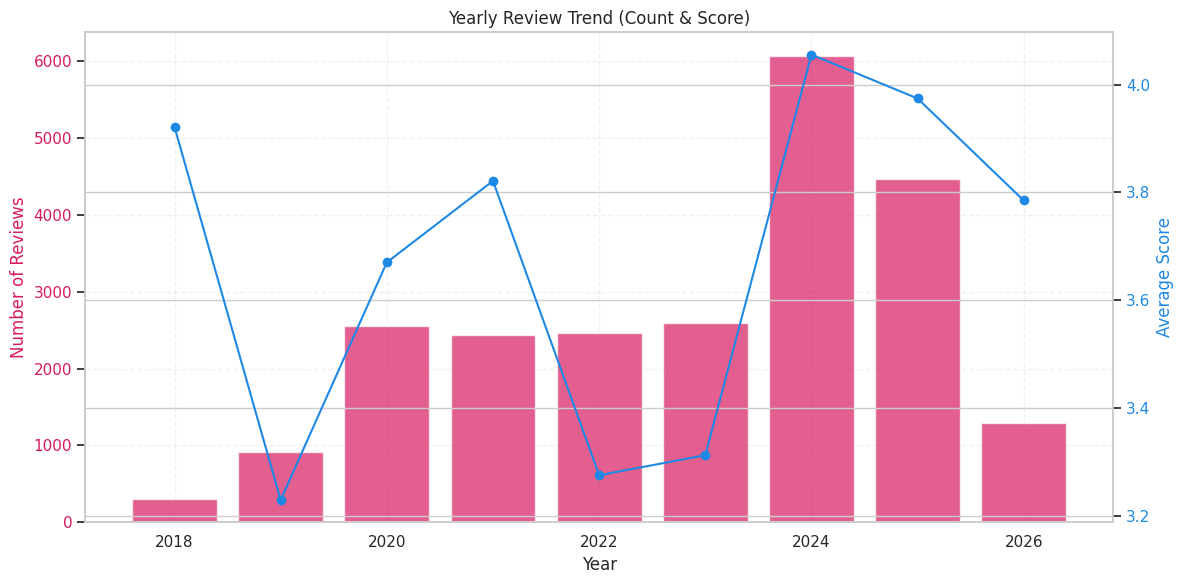

In [58]:
# Convert date and extract year
df['at'] = pd.to_datetime(df['at'], errors='coerce')
df['review_year'] = df['at'].dt.year

# Aggregate yearly data
yearly = df.groupby('review_year').agg(
    review_count=('review_year', 'size'),
    avg_score=('score', 'mean')
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar: review count
bars = ax1.bar(yearly.index, yearly['review_count'], color="#D81B60", alpha=0.7)
ax1.set_ylabel("Number of Reviews", color="#D81B60")
ax1.tick_params(axis='y', labelcolor="#D81B60")

# Line: average score
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['avg_score'], color="#1E88E5", marker='o')
ax2.set_ylabel("Average Score", color="#1E88E5")
ax2.tick_params(axis='y', labelcolor="#1E88E5")

# Title + grid
ax1.set_xlabel("Year")
plt.title("Yearly Review Trend (Count & Score)")
ax1.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

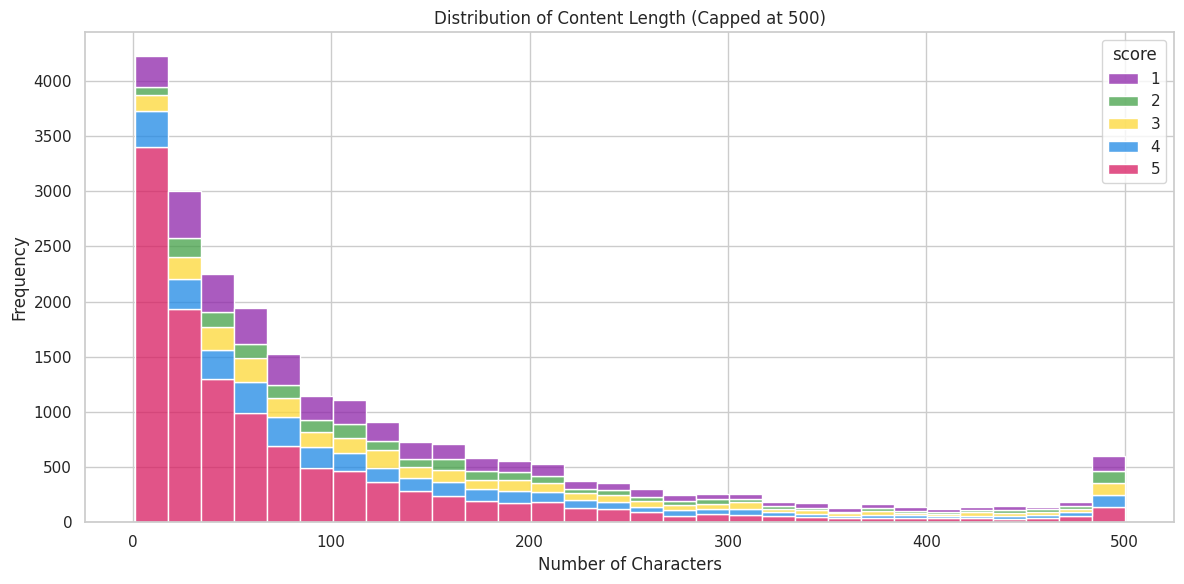

In [65]:
df['content_length'] = df['content'].astype(str).apply(len)
df['content_length_capped'] = df['content_length'].clip(upper=500)

# tetap 12345 (sesuai keinginan kamu)
hue_order = [1, 2, 3, 4, 5]

# INI KUNCI: mapping warna dibalik
color_palette = {
    1: "#8E24AA",  # purple (top)
    2: "#43A047",  # green
    3: "#FDD835",  # yellow
    4: "#1E88E5",  # blue
    5: "#D81B60"   # pink (BOTTOM)
}

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='content_length_capped',
    hue='score',
    hue_order=hue_order,
    bins=30,
    palette=color_palette,
    multiple='stack',
    edgecolor='white'
)

plt.title("Distribution of Content Length (Capped at 500)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

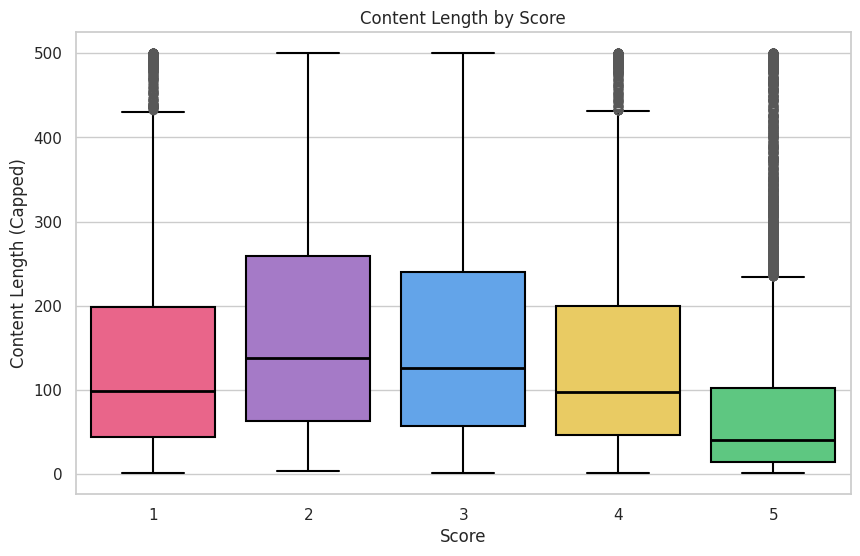

In [68]:
df['score'] = df['score'].astype(int)
df['content_length_capped'] = df['content_length'].clip(upper=500)

# Brighter & fresher palette (tidak terlalu dark)
color_palette = {
    1: "#FF4F81",  # pink (lebih bright)
    2: "#A66DD4",  # purple (lebih soft bright)
    3: "#4DA3FF",  # blue (lebih fresh)
    4: "#FFD84D",  # yellow (bright)
    5: "#4CD97B"   # green (fresh green)
}

plt.figure(figsize=(10,6))

sns.boxplot(
    x='score',
    y='content_length_capped',
    data=df,
    hue='score',
    palette=color_palette,
    dodge=False,
    legend=False,
    linewidth=1.5,
    boxprops=dict(edgecolor='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

plt.title("Content Length by Score")
plt.xlabel("Score")
plt.ylabel("Content Length (Capped)")

plt.show()

/tmp/ipykernel_35560/2776024748.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


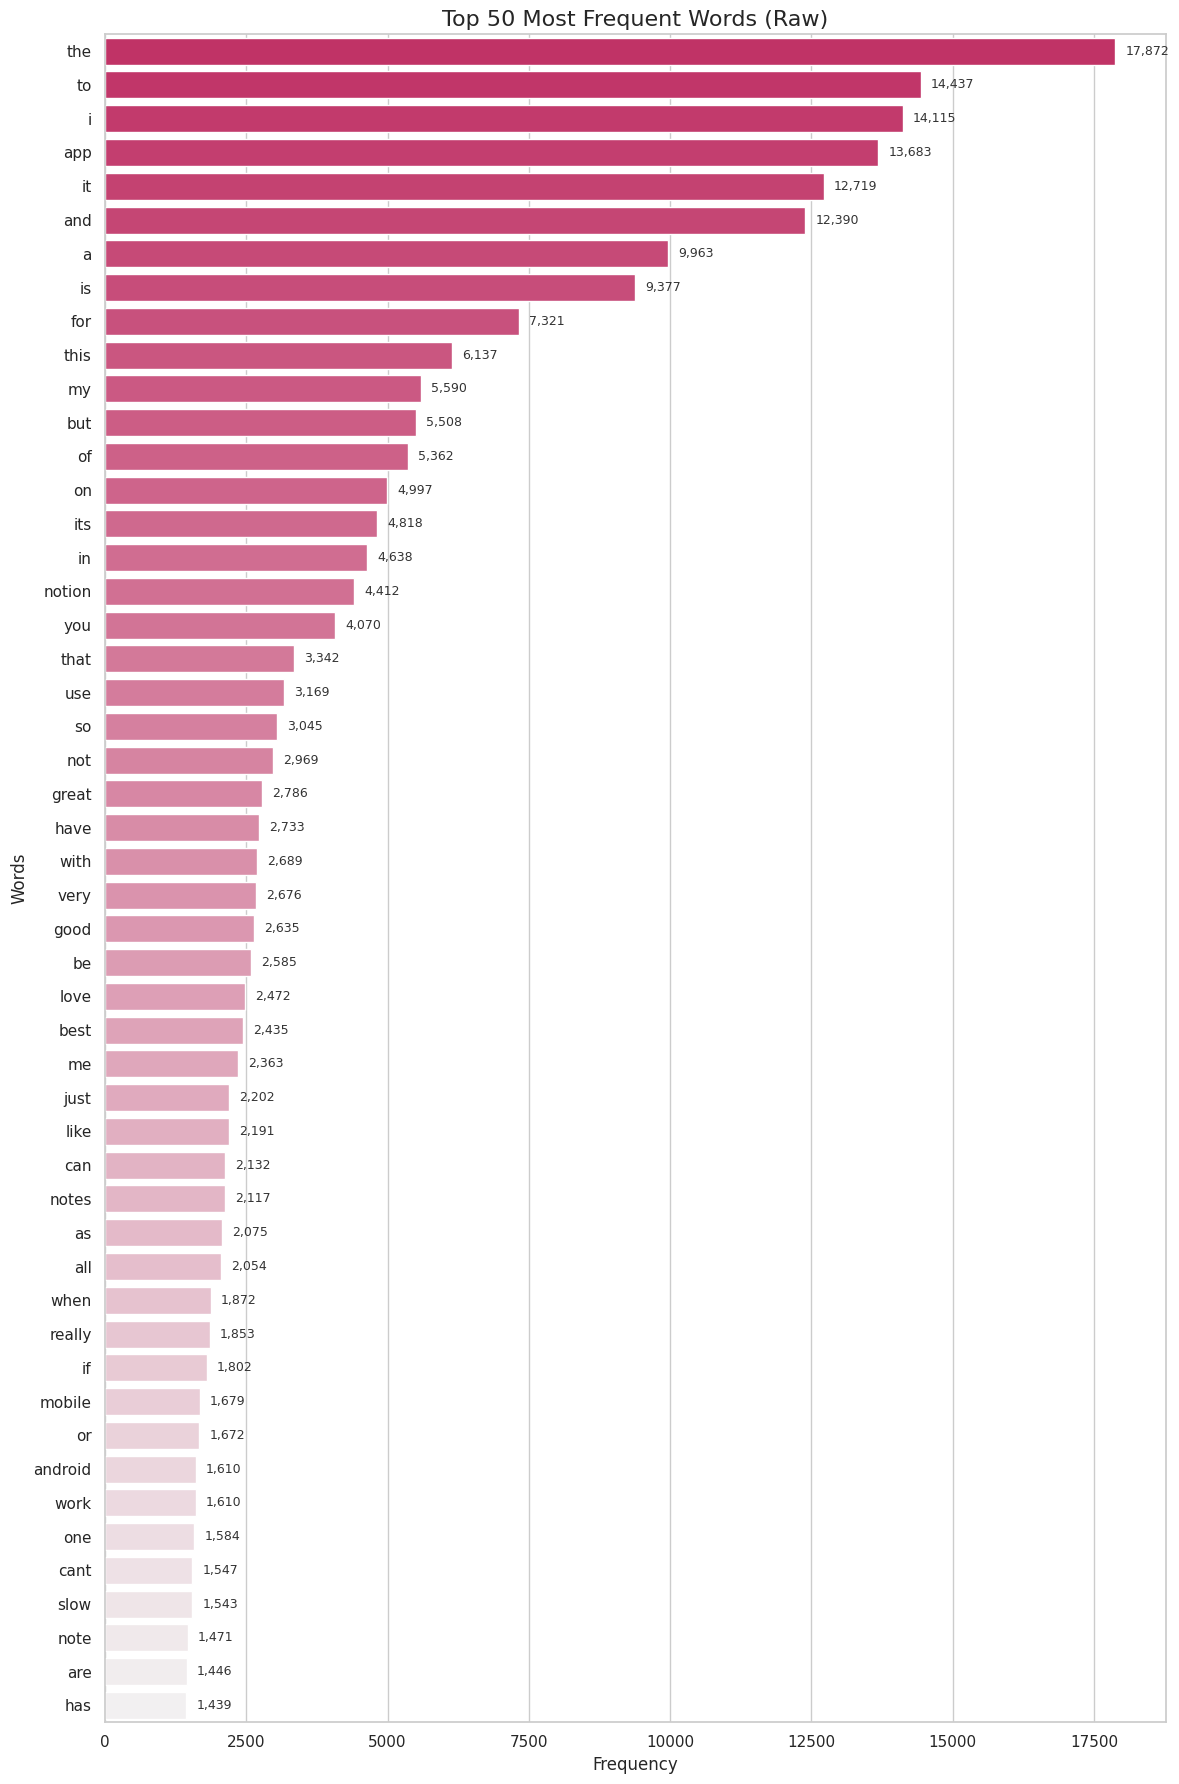

In [40]:
# Text Preparation
def prepare_text(series):
    text = " ".join(series.astype(str)).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text.split()

# Get Top Words
def get_top_words(words, n=50):
    counter = Counter(words)
    return pd.DataFrame(counter.most_common(n), columns=['word', 'count'])

# Plot Function
def plot_top_words(df_words):
    plt.figure(figsize=(12, 18))

    colors = sns.light_palette("#D81B60", n_colors=len(df_words), reverse=True)

    ax = sns.barplot(
        x='count',
        y='word',
        data=df_words,
        palette=colors
    )

    # Add labels
    max_val = df_words['count'].max()
    for i, val in enumerate(df_words['count']):
        ax.text(
            val + max_val * 0.01,
            i,
            f'{val:,}',
            va='center',
            fontsize=9,
            color='#333'
        )

    ax.set_title("Top 50 Most Frequent Words (Raw)", fontsize=16)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Words")

    plt.tight_layout()
    plt.show()


# Pipeline Execution
words = prepare_text(df['content'])
words_df = get_top_words(words, n=50)
plot_top_words(words_df)

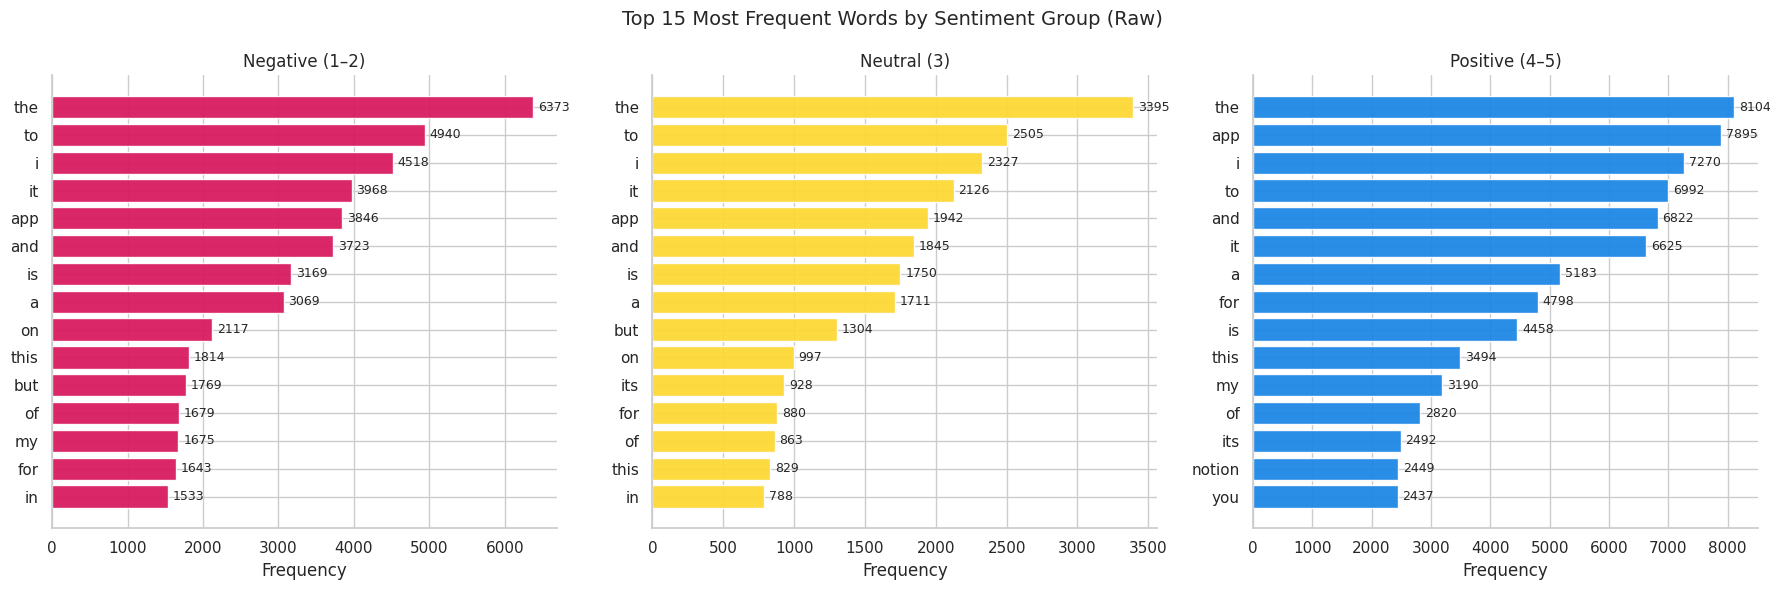

In [61]:
from collections import Counter
import re
import matplotlib.pyplot as plt

# Function to extract top words
def extract_top_words(data, top_n=15):
    text = " ".join(data['content'].astype(str)).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    return Counter(words).most_common(top_n)

# Define sentiment groups
sentiment_groups = {
    'Negative (1–2)': df[df['score'].isin([1, 2])],
    'Neutral (3)': df[df['score'] == 3],
    'Positive (4–5)': df[df['score'].isin([4, 5])]
}

# Strong & consistent colors (match previous style)
colors = ['#D81B60', '#FDD835', '#1E88E5']
# pink, yellow, blue (lebih bold dari pastel)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ((label, subset), color) in zip(axes, zip(sentiment_groups.items(), colors)):

    top_words = extract_top_words(subset, top_n=15)

    # Handle empty case
    if len(top_words) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.set_title(label)
        ax.axis('off')
        continue

    words, counts = zip(*top_words)

    bars = ax.barh(words, counts, color=color, alpha=0.95)
    ax.invert_yaxis()

    # Add value labels
    max_val = max(counts)
    for i, v in enumerate(counts):
        ax.text(v + max_val*0.01, i, f'{v}', va='center', fontsize=9)

    # Titles & labels
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Frequency")

    # Clean style
    ax.spines[['top', 'right']].set_visible(False)

# Main title
plt.suptitle("Top 15 Most Frequent Words by Sentiment Group (Raw)", fontsize=14)

plt.tight_layout()
plt.show()